# UČITAVANJE DATASETA ZA KREDITNE KARTICE

In [ ]:
import tensorflow as tf


In [ ]:
# DA OSTANE FIKSNO

import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape


(284807, 31)

In [ ]:
df.info()  # VIDIMO DA NEMA NEDOSTAJUĆIH VREDNOSTI ŠTO JE SUPER

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df['Class'].value_counts()

# IMAMO 284 315 DOBRIH TRANSAKCIJA, A 492 LAZNE TRANSAKCIJE!

,count
Class,
0,284315
1,492


In [ ]:
df['Class'].value_counts(normalize=True)

# OVDE MOZEMO DA VIDIMO DA JE 99,82% TRANSAKCIJA USTVARI PRAVIH, A DA JE 0,017% TRANSAKCIJA PREVARA

,proportion
Class,
0,0.998273
1,0.001727


# ANALIZA PODATAKA I VIZUALIZACIJA

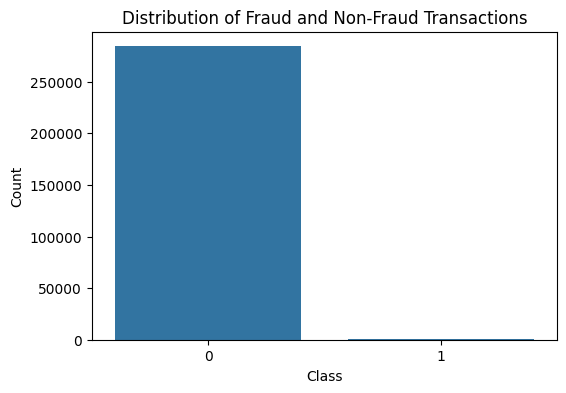

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title('Distribution of Fraud and Non-Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()



# ODAVDE MOZEMO DA ZAKLJUCIMO DA JE DATASET VEOMA VEOMA NEURAVNOTEZEN VIDIMO DA JE VECINA PODATAKA IZ PRVE KLASE ODNOSNO DA SU TRANSAKCIJE DOBRE (0), A JAKO MALI BROJ IZ GRUPE TRANSAKCIJA KOJE SU PREVARA (1)

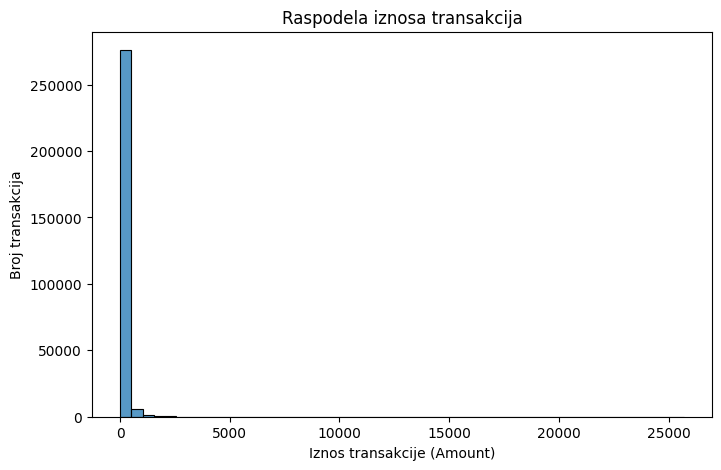

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)

plt.title('Raspodela iznosa transakcija')
plt.xlabel('Iznos transakcije (Amount)')
plt.ylabel('Broj transakcija')

plt.show()

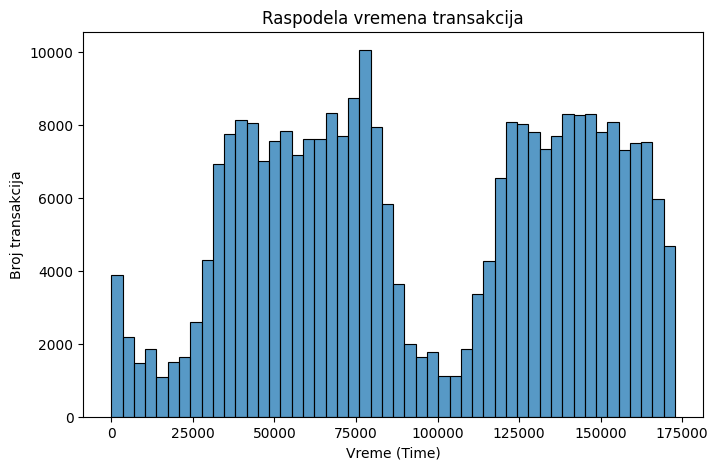

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Time'], bins=50)

plt.title('Raspodela vremena transakcija')
plt.xlabel('Vreme (Time)')
plt.ylabel('Broj transakcija')

plt.show()

In [ ]:
df.isnull().sum()

# ne postoje nedostajuće vrednosti ni u jednoj od 31 kolone pa zbog toga nije potrebno da vrsimo dodatno preprocesiranje u vidu popunjavanja ili uklanjanja nedostajućih podataka

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# PREPROCESSING PODATAKA

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])

df['scaled_Time'] = scaler.fit_transform(df[['Time']])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_Amount,scaled_Time
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964,-1.996583
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475,-1.996583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686,-1.996562
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534,-1.996562
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403,-1.996541


In [ ]:
df = df.drop(['Amount', 'Time'], axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_Amount,scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


# PODELA NA CILJNU I OSTATAK


In [ ]:
X = df.drop('Class', axis=1)

y = df['Class']

In [ ]:
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


# PODELA NA TRAIN I TEST SKUP

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(227845, 30)
(56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


# OSNOVNI MODEL (1. MODEL)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model_1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9927 - loss: 0.0320 - val_accuracy: 0.9994 - val_loss: 0.0037
Epoch 2/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0045 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 3/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 4/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 5/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 6/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 7/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 8/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.

# EVALUACIJA MODELA

In [ ]:
test_loss, test_accuracy = model_1.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0029
Test Loss: 0.002896486781537533
Test Accuracy: 0.9993680119514465


# PREDIKCIJE

In [ ]:
y_pred_prob = model_1.predict(X_test)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 862us/step


In [ ]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# EVALUACIONE METRIKE

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9993679997191109
Precision: 0.8163265306122449
Recall: 0.8163265306122449
F1-score: 0.8163265306122449


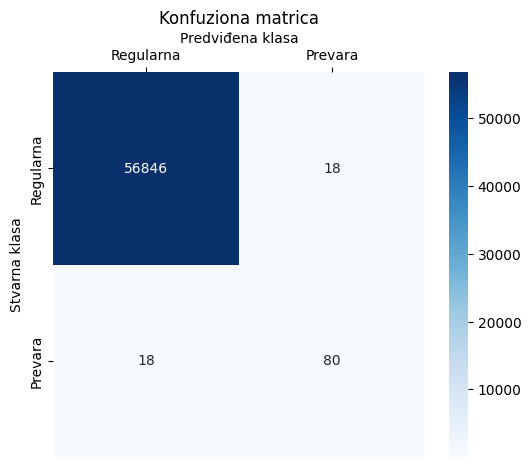

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# KONFUZIONA MATRICA

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Regularna', 'Prevara'],
    yticklabels=['Regularna', 'Prevara']
)


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Konfuziona matrica')

plt.show()

# ROC-AUC I ROC KRIVA

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9807002816602162


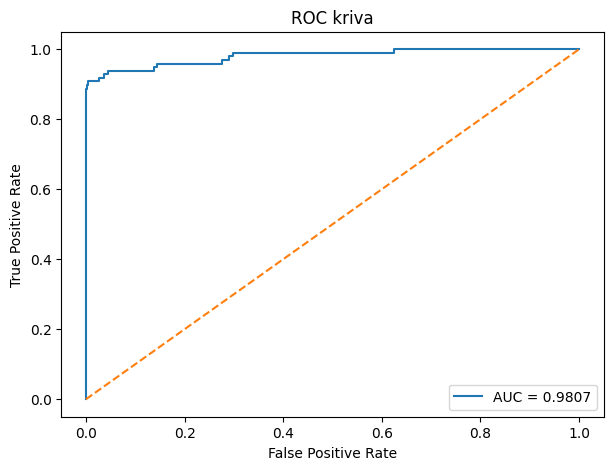

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC kriva')
plt.legend()

plt.show()

# PRIMENA CLASS WEIGHTS MODELA (2. MODEL)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights_values[0],
    1: class_weights_values[1]
}

class_weights

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}

In [ ]:
model_2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history2 = model_2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping_2],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9560 - loss: 0.3245 - val_accuracy: 0.9738 - val_loss: 0.1411
Epoch 2/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9628 - loss: 0.1876 - val_accuracy: 0.9715 - val_loss: 0.1247
Epoch 3/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9627 - loss: 0.1731 - val_accuracy: 0.9676 - val_loss: 0.1238
Epoch 4/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9688 - loss: 0.1408 - val_accuracy: 0.9708 - val_loss: 0.1047
Epoch 5/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9681 - loss: 0.1480 - val_accuracy: 0.9671 - val_loss: 0.1184
Epoch 6/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9703 - loss: 0.1370 - val_accuracy: 0.9678 - val_loss: 0.1143
Epoch 7/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9689 - loss: 0.1191 - val_accuracy: 0.9688 - val_loss: 0.1022
Epoch 8/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9720 - loss: 0.1094 - val_accuracy: 0.

EVALUACIJA DRUGOG MODELA

In [ ]:
test_loss_2, test_accuracy_2 = model_2.evaluate(X_test, y_test)

y_pred_prob_2 = model_2.predict(X_test)
y_pred_2 = (y_pred_prob_2 > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2)
recall_2 = recall_score(y_test, y_pred_2)
f1_2 = f1_score(y_test, y_pred_2)
auc_2 = roc_auc_score(y_test, y_pred_prob_2.ravel())

print("Accuracy:", accuracy_2)
print("Precision:", precision_2)
print("Recall:", recall_2)
print("F1-score:", f1_2)
print("ROC-AUC:", auc_2)


# VIDIMO DA JE MODEL DOBAR I PODIGAO JE VREDNOST RECALL-A ALI NA UŠTRP PRECISIONA KOJI SE ZNATNO SMANJIO (MODEL JE SAD ZA SVAKI REKAO DA JE PREVARA, PA NE BIH DA BUDE NAJBOLJI IPAK JE ZA SAD MODEL 1 NAJBOLJI)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9791 - loss: 0.0687
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Accuracy: 0.9791088796039464
Precision: 0.07075471698113207
Recall: 0.9183673469387755
F1-score: 0.13138686131386862
ROC-AUC: 0.9808733584176496


# HIPERPARAMETRI I KERAS TUNER (3. MODEL)

In [ ]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(
        units=hp.Int('neuroni_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))

    model.add(Dropout(
        rate=hp.Choice('dropout_1', values=[0.2, 0.3, 0.4])
    ))

    model.add(Dense(
        units=hp.Int('neuroni_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))

    model.add(Dropout(
        rate=hp.Choice('dropout_2', values=[0.2, 0.3, 0.4])
    ))

    model.add(Dense(1, activation='sigmoid'))

    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_rezultati',
    project_name='credit_card_fraud'
)

Reloading Tuner from tuner_rezultati/credit_card_fraud/tuner0.json


In [ ]:
early_stopping_tuner = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping_tuner],
    verbose=1
)

In [ ]:
best_hp = tuner.get_best_hyperparameters()[0]

print("Prvi sloj:", best_hp.get('neuroni_1'))
print("Dropout 1:", best_hp.get('dropout_1'))

print("Drugi sloj:", best_hp.get('neuroni_2'))
print("Dropout 2:", best_hp.get('dropout_2'))

print("Learning rate:", best_hp.get('learning_rate'))

# NAJBOLJI PARAMETRI PRONADJENI KROZ FINE-TUNING:

Prvi sloj: 128
Dropout 1: 0.3
Drugi sloj: 64
Dropout 2: 0.2
Learning rate: 0.0001


# EVALUACIJE TREĆEG MODELA

In [ ]:
best_model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
test_loss_best, test_accuracy_best = best_model.evaluate(X_test, y_test)

y_pred_prob_best = best_model.predict(X_test)
y_pred_best = (y_pred_prob_best > 0.5).astype(int)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_pred_prob_best.ravel())

print("Accuracy:", accuracy_best)
print("Precision:", precision_best)
print("Recall:", recall_best)
print("F1-score:", f1_best)
print("ROC-AUC:", auc_best)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9994 - loss: 0.0029
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 886us/step
Accuracy: 0.9993679997191109
Precision: 0.81
Recall: 0.826530612244898
F1-score: 0.8181818181818182
ROC-AUC: 0.9805021720280683


# POREĐENJA PERFORMANSI

In [ ]:
import pandas as pd

# Kreiranje tabele sa rezultatima
rezultati = pd.DataFrame({
    'Metrika': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'ROC-AUC'
    ],

    'Model 1 (Osnovni)': [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],

    'Model 2 (Class Weights)': [
        accuracy_2,
        precision_2,
        recall_2,
        f1_2,
        auc_2
    ],

    'Model 3 (Keras Tuner)': [
        accuracy_best,
        precision_best,
        recall_best,
        f1_best,
        auc_best
    ]
})

# Postavljanje kolone Metrika kao indeksa
rezultati.set_index('Metrika', inplace=True)

display(
    rezultati.style
    .format("{:.4f}")
    .set_caption("Poređenje performansi modela")
    .background_gradient(cmap='Blues', axis=1)
)

,Model 1 (Osnovni),Model 2 (Class Weights),Model 3 (Keras Tuner)
Metrika,,,
Accuracy,0.9994,0.9791,0.9994
Precision,0.8163,0.0708,0.8100
Recall,0.8163,0.9184,0.8265
F1-score,0.8163,0.1314,0.8182
ROC-AUC,0.9807,0.9809,0.9805


In [ ]:
rezultati_proc = rezultati * 100

display(
    rezultati_proc.style
    .format("{:.2f}%")
    .set_caption("Poređenje performansi modela (%)")
    .background_gradient(cmap='Blues', axis=1)
)

,Model 1 (Osnovni),Model 2 (Class Weights),Model 3 (Keras Tuner)
Metrika,,,
Accuracy,99.94%,97.91%,99.94%
Precision,81.63%,7.08%,81.00%
Recall,81.63%,91.84%,82.65%
F1-score,81.63%,13.14%,81.82%
ROC-AUC,98.07%,98.09%,98.05%


In [ ]:
# Nakon modela 1 (već imaš ovo)
fpr_1, tpr_1, _ = roc_curve(y_test, y_pred_prob)

# Nakon modela 2
fpr_2, tpr_2, _ = roc_curve(y_test, y_pred_prob_2.ravel())

# Nakon modela 3
fpr_3, tpr_3, _ = roc_curve(y_test, y_pred_prob_best.ravel())

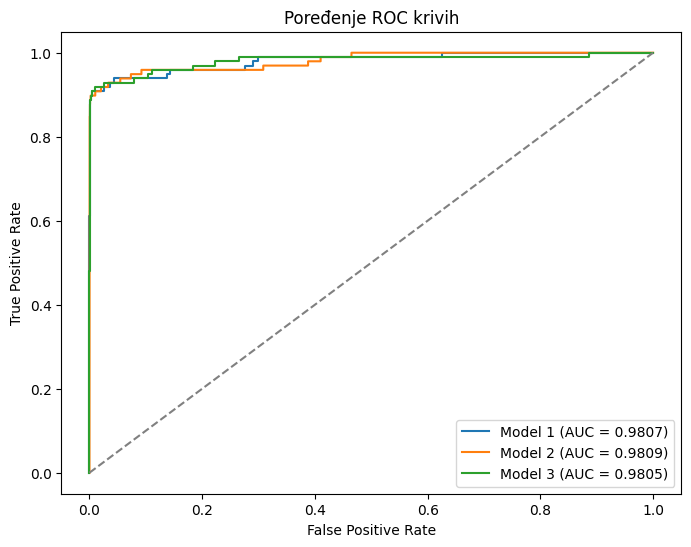

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_1, tpr_1, label=f'Model 1 (AUC = {auc:.4f})')
plt.plot(fpr_2, tpr_2, label=f'Model 2 (AUC = {auc_2:.4f})')
plt.plot(fpr_3, tpr_3, label=f'Model 3 (AUC = {auc_best:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Poređenje ROC krivih')
plt.legend()
plt.show()

# ČUVANJE MODELA

In [ ]:
best_model.save('credit_card_fraud_model.keras')

In [ ]:
print("Prvi sloj:", best_hp.get('neuroni_1'))
print("Dropout 1:", best_hp.get('dropout_1'))

print("Drugi sloj:", best_hp.get('neuroni_2'))
print("Dropout 2:", best_hp.get('dropout_2'))

print("Learning rate:", best_hp.get('learning_rate'))

Prvi sloj: 128
Dropout 1: 0.3
Drugi sloj: 64
Dropout 2: 0.2
Learning rate: 0.0001


In [ ]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'scaler.pkl', 'credit_card_fraud_model.keras', 'tuner_rezultati', 'sample_data']
